We wcześniejszych notatnikach działałem na RandomForestRegressor/Classifier, była to metoda lasu losowego, która polega na uśrednieniu prognozy wielu drzew decyzyjnych.Metodę lasu losowego nazywamy „metodą zespołową (ensemble method)”. Z definicji metody zespołowe łączą prognozy kilku modeli (np. kilku drzew w przypadku lasów losowych).Dzisiaj nauczę się następnej "metody zespołowej" jaką jest wzmacnianie gradientowe.XGBoost działa inaczej niż Las Losowy – buduje drzewa sekwencyjnie (jedno po drugim), gdzie każde kolejne drzewo skupia się na poprawianiu błędów popełnionych przez poprzednie. Dzięki temu potrafi wyłapać subtelne i trudne wzorce w skomplikowanych danych molekularnych. Porównam go z RandomForest.
https://www.kaggle.com/code/alexisbcook/xgboost

Zaczynam od wczytania potrzebnych nam bibliotek. Tutaj nowością XGBClassifier:

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

Dodaje dane (korzystam z tych samych co w poprzednich dniach)

In [10]:
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/clintox.csv.gz"
df = pd.read_csv(url)
df = df.dropna(subset=['smiles', 'CT_TOX']) #dropna(subset...) oznacza że jeśli w bazie trafi się wiersz który nie ma zapisanego smiles albo brakuje CT_TOX to go wyrzuca

In [ ]:
Uzyskywanie Fingerprintów:

In [12]:
X_lista = [] #Tu zbieram fingerprinty (wektory)
valid_indices = [] #Tu zbieram poprawne wierszy

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

for idx, sml in enumerate(df['smiles']): #Wyciągam smiles i pozycję w tabeli
    mol = Chem.MolFromSmiles(sml)
    if mol is not None:
        fp = morgan_gen.GetFingerprint(mol)
        bit_string = fp.ToBitString() #Wektor zamieniam na string
        bit_vector = [int(bit) for bit in bit_string]
        X_lista.append(bit_vector)
        valid_indices.append(idx)

[00:12:40] Explicit valence for atom # 0 N, 4, is greater than permitted
[00:12:40] Can't kekulize mol.  Unkekulized atoms: 9
[00:12:40] Can't kekulize mol.  Unkekulized atoms: 4
[00:12:40] Can't kekulize mol.  Unkekulized atoms: 4


Bezpieczna synchronizacja:

In [13]:
df_clean = df.iloc[valid_indices].reset_index(drop=True) #Tworzenie czystej tabeli z poprawnymi wierszami
X = np.array(X_lista)
Y = df_clean["CT_TOX"].values

Podział na trening i test:

In [65]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)
 #stratify = pilnuje, aby unikalne proporcje zostały po równo zachowane w obu zbiorach.
neg_count = (Y_train == 0).sum()
pos_count = (Y_train == 1).sum()
skala_wag= neg_count / pos_count #mnożnik kary który nałożymy na algorytm
print("Związki toksyczne w trenowanych:", pos_count)
print("Związki bezpieczne w trenowanych:", neg_count)

Związki toksyczne w trenowanych: 90
Związki bezpieczne w trenowanych: 1094


Trenowanie modelu:

In [72]:
model_xgb = XGBClassifier(
    scale_pos_weight=skala_wag,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    max_depth=2,
    eval_metric="logloss"
)
model_xgb.fit(X_train, Y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Wyskoczyła śmieszna wizytówka modelu, bardzo fajny gadżet.
Czas na próg decyzyjny. Zamiast strzału 0 albo 1, wyciągam precyzyjne odczyty prawdopodobieństwa i bierzemy tylko kolumne numer 1 (szansa na bycie trucizna). Ustalam rygor na 30% każdy wynik równy lub wyższy 30% ulega zamianie na 1 za pomocą astype(int)

In [74]:
prawdopodobienstwo = model_xgb.predict_proba(X_test)
szansa_toksycznosci = prawdopodobienstwo[:, 1]
nowy_prog = 0.30
Y_pred_xgb = (szansa_toksycznosci >= nowy_prog).astype(int)


Graficzne zestawienie macierzy:

T: 22
B: 274


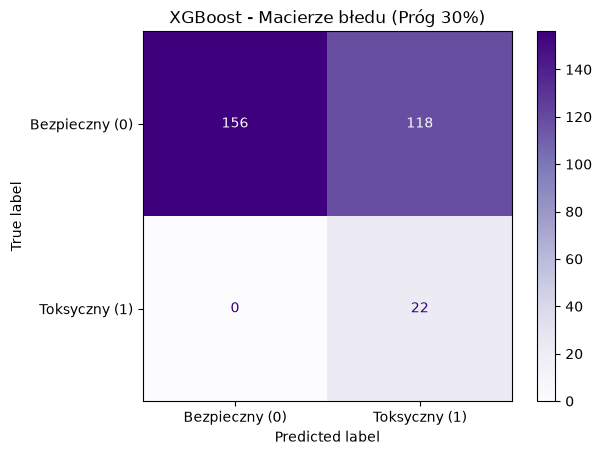

In [75]:
cm = confusion_matrix(Y_test, Y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bezpieczny (0)", "Toksyczny (1)"])
disp.plot(cmap=plt.cm.Purples)
plt.title(f"XGBoost - Macierze błedu (Próg {int(nowy_prog*100)}%)")
plt.show

toksyny_w_test = np.sum(Y_test==1)
bezpieczne_w_test = np.sum(Y_test==0)
print("T:", toksyny_w_test)
print("B:", bezpieczne_w_test)

Wnioski dopisze rano ;)